In [1]:
from matplotlib.ticker import LinearLocator
from jax import config, jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax
import sys
from functools import partial

# --- Standard Library ---
sys.path.append("../src")

# --- Third-Party Packages ---

# JAX Config
jax.config.update("jax_platform_name", "cpu")
config.update("jax_enable_x64", True)

In [2]:
# --- Local Application / Library Specibcic Imports ---
from configuration.rte1d_settings_ex3_oerfm import get_config
from constraints.continuous1d_oe import (
    OddEvenDecompositionPointwiseBoundaryConstraint1D as BC,
    OddEvenDecompositionPointwiseInteriorConstraint1D as EQ,
)
from geometry.meshxd_ds import UniformMeshXV
from modules.generator import Sample1D
from modules.solution import OddEvenDecompositionConstructor1D
from solver.least_square import solve
from utils.integrate import leggauss

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Mp_j = rte_config.model.Mp["j"]
Mp_r = rte_config.model.Mp["r"]
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["j/r"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
bdy_value = rte_config.model.bdy_cond
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_j = UniformMeshXV(domain=domain, strides=strides)
mesh_r = UniformMeshXV(domain=domain, strides=strides)
print(kn)
# print(f"Mp_j: {Mp_j}, Mp_r: {Mp_r} - Jn_j: {Jn["j"]}, Jn_r: {Jn["g"]}")

0.5


In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
# dummy_x, dummy_v = jnp.split(jnp.array([0.0, 0.0]), 2, axis=0)
params = {}
# eq_instance = rte.apply(params, dummy_x, dummy_v)
# bc_instance = bc.apply(params, dummy_x, dummy_v)

In [6]:
# (3, Mp_j*Jn_j+Mp_r*Jn_r), (Mp_j*Jn_j+Mp_r*Jn_r,)
# eq_instance.shape, bc_instance.shape

In [7]:
def eq_fn(x, v):
    return partial(rte.apply, params)(x, v)


def bc_fn(x, v):
    return partial(bc.apply, params)(x, v)


def rhs_fn(x, v):
    quadratures = leggauss(num_quads, interval=[-1.0, 1.0])

    def q_sym(x, v):
        return 0.5 * (source_fn(x, v) + source_fn(x, -v))

    def q_asym(x, v):
        return 0.5 * (source_fn(x, v) - source_fn(x, -v))

    avg_q = integrator(q_sym, quadratures, argnum=1)(x) / 2
    rhs = jnp.array([
        avg_q,
        kn**2 * q_sym(x, v).squeeze(),
        kn * q_asym(x, v).squeeze(),
    ])
    return rhs


def integrator(fn, quadratures, argnum):
    pts, ws = quadratures

    def integral_fn(*args):
        args = list(args)
        in_axes_ = [None] * len(args)
        args.insert(argnum, pts)
        in_axes_.insert(argnum, int(0))
        vmap_fns = vmap(fn, in_axes=in_axes_, out_axes=-1)(*args)
        out = jnp.dot(vmap_fns, ws).squeeze()
        return jnp.array(out)

    return integral_fn


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

In [8]:
sampler = Sample1D(

    domain=domain, collocation_sizes=collocation_sizes, mode=mode)
xv_int, xv_bcl, xv_bcr = (
    sampler.pts_int,
    sampler.pts_left,
    sampler.pts_right,
)

In [9]:
# Evaluate the functions
bc_left = vmap_bc_fn(*xv_bcl)
bc_right = vmap_bc_fn(*xv_bcr)

In [10]:
eq_int = vmap_eq_fn(*xv_int)

In [11]:
rhs_int = vmap_rhs_fn(*xv_int)

In [12]:
print(f"Boundary: {bc_left.shape}, {bc_right.shape}, Interior: {eq_int.shape}")

Boundary: (128, 512), (128, 512), Interior: (3968, 3, 512)


In [13]:
# Save the data
matrix_A = np.concatenate(
    [bc_left, bc_right, eq_int.reshape(-1, num_unknowns)], axis=0)
vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size = bc_left.shape[0]
vector_b[:bdy_size, 0] = bdy_value["f_l"](xv_bcl[-1])
vector_b[bdy_size: 2 * bdy_size, 0] = bdy_value["f_r"](xv_bcr[-1])
vector_b[2 * bdy_size:, 0] = rhs_int.reshape(-1)
print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (12160, 512), Vector b: (12160, 1)


In [14]:
vector_U = solve(matrix_A, vector_b, c=regularizer)

print(f"Vector U: {vector_U.shape}")

Vector U: (512, 1)


In [15]:
np.linalg.norm(matrix_A @ vector_U - vector_b) / np.linalg.norm(vector_b)

0.051145256226684234

In [16]:
from numpy.linalg import cond

print(f" Matrix A Condition number: {cond(matrix_A):.6e}")
print(f" Vector b Condition number: {cond(vector_b):.6e}")

print(" Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print(" Vector b 内存 %.2f MB" % (vector_b.nbytes / 1024**2))

num_zero = np.sum(matrix_A == 0).item()
total = matrix_A.size
sparsity = num_zero / total
print(f" A的稀疏度 = {sparsity:.2%} (零元素比例)")
num_zero = np.sum(vector_b == 0).item()
total = vector_b.size
sparsity = num_zero / total
print(f" b的稀疏度 = {sparsity:.2%} (零元素比例)")

 Matrix A Condition number: 2.906400e+13
 Vector b Condition number: 1.000000e+00
 Matrix A 内存 47.50 MB
 Vector b 内存 0.09 MB
 A的稀疏度 = 61.48% (零元素比例)
 b的稀疏度 = 98.95% (零元素比例)


In [17]:
# data = np.load("../src/data/weights.npz")
# vector_U = data["coefficients"]

In [ ]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns,
)

constructor = OddEvenDecompositionConstructor1D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [19]:
def approx_fn(x, v):
    return partial(constructor.apply, params)(x, v)

In [20]:
dummy_z = jnp.array([0.7, -0.5])
dummy_x, dummy_v = jnp.split(dummy_z, 2, axis=0)
print(f"f({dummy_z}) = {jit(approx_fn)(dummy_x, dummy_v)}")

f([ 0.7 -0.5]) = 0.006620600743190153


In [21]:
vmap_approx_fn = vmap(approx_fn)

In [22]:
# def plot_boundary_solutions():
#     """绘制边界解 - 高清一行两列布局"""
#     fig, (ax1, ax2) = plt.subplots(
#         1,
#         2,
#         figsize=(16, 6),
#         dpi=500,
#         sharey=True,
#         constrained_layout=True,
#     )

#     # 左边界 (x=0, v > 0)
#     v_left = xv_bcl[1]
#     f_left = vmap_approx_fn(*xv_bcl)
#     f_ex_left = jnp.ones_like(f_left) / 2
#     ax1.plot(v_left, f_ex_left, "-", color="#94A3C0", linewidth=3, label="Inflow")
#     ax1.plot(v_left, f_left, "k--", alpha=0.5, linewidth=3, label="Numerical")
#     ax1.set_xlim([-0.1, 1.1])
#     ax1.set_ylim([-0.1, 1.1])
#     ax1.set_xlabel(r"$v$", fontsize=14)
#     ax1.set_ylabel(r"$f(0, v)$", fontsize=14)
#     ax1.set_title("Left Boundary", fontsize=14, pad=10)
#     # ax1.grid(alpha=0.3, linestyle=":", linewidth=0.8)
#     ax1.legend(frameon=False, loc="best")

#     # 右边界 (x=1, v < 0)
#     v_right = xv_bcr[1]  # 使用正确的索引获取速度坐标
#     f_right = vmap_approx_fn(*xv_bcr)
#     f_ex_right = jnp.zeros_like(f_right)
#     ax2.plot(v_right, f_ex_right, "-", color="#94A3C0", linewidth=3, label="Inflow")
#     ax2.plot(v_right, f_right, "k--", alpha=0.5, linewidth=3, label="Numerical")
#     ax2.set_xlim([-1.1, 0.1])
#     ax2.set_ylim([-0.1, 1.1])
#     ax2.set_xlabel(r"$v$", fontsize=14)
#     ax2.set_ylabel(r"$f(1, v)$", fontsize=14)
#     ax2.set_title("Right Boundary", fontsize=14, pad=10)
#     # ax2.grid(alpha=0.3, linestyle=":", linewidth=0.8)
#     ax2.legend(frameon=False, loc="best")

#     plt.show()
#     plt.close()


# # 使用示例
# plot_boundary_solutions()

In [23]:
data = jnp.load(f"../src/data/rte1d_ex3_ref_{kn:.1e}.npz")
mesh_x, mesh_v, F = data["mesh_x"], data["mesh_v"], data["F"]
X, V = jnp.meshgrid(mesh_x, mesh_v)
XV = jnp.stack([X, V], axis=-1)
F_hat = vmap_approx_fn(

    *jnp.split(XV.reshape(-1, 2), 2, axis=1)).reshape(X.shape)
print(kn)
# np.savez("../src/data/rte1d_solutions_kn.npz", X=X, V=V, F=F, F_hat=F_hat)

0.5


In [24]:
jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F)

Array(0.02799041, dtype=float64)

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


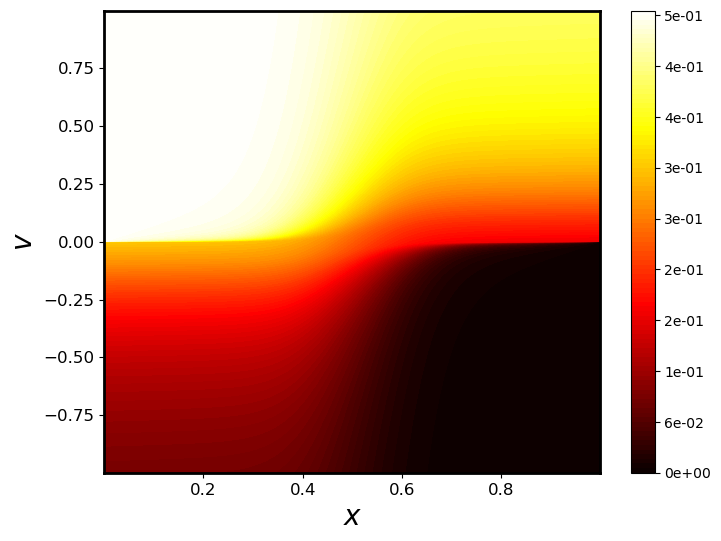

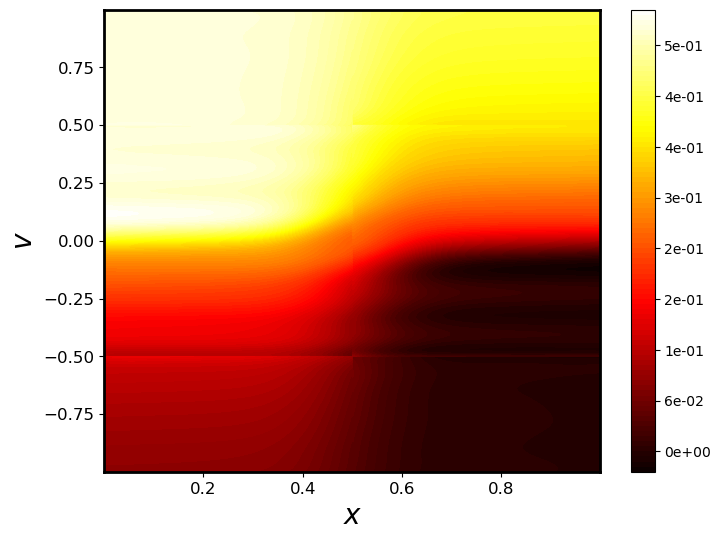

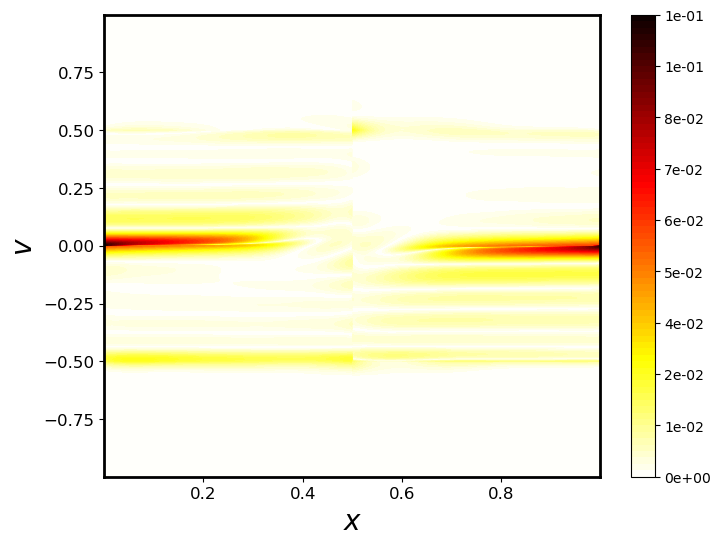

In [25]:
font_format = {"family": "Times New Roman", "size": 20}

# 第一张图：参考解
plt.figure(figsize=(8, 6))
plt.contourf(X, V, F, 100, cmap="hot")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
# plt.title("Reference solution", font_format)
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)
plt.show()
plt.close()

# 第二张图：OE-APRFM 解
plt.figure(figsize=(8, 6))
plt.contourf(X, V, F_hat, 100, cmap="hot")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
# plt.title("OE-APRFM solution", font_format)
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)
plt.show()
plt.close()

# 第三张图：误差
plt.figure(figsize=(8, 6))
plt.contourf(X, V, np.abs(F - F_hat), 100, cmap="hot_r")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
# plt.title("Error", font_format)
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)
plt.show()
plt.close()

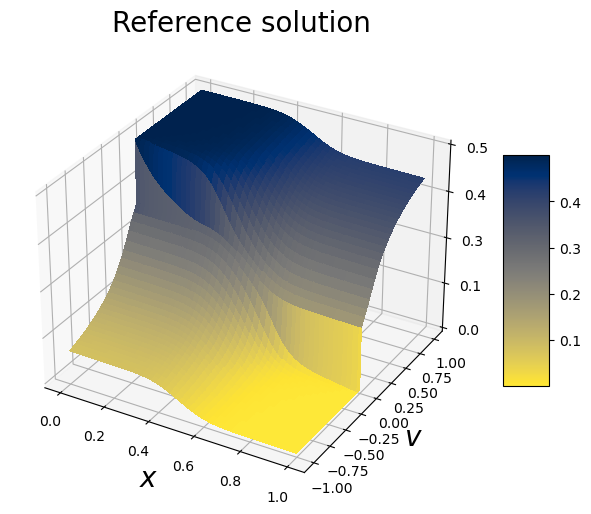

AttributeError: 'Figure' object has no attribute 'colorbaplt'

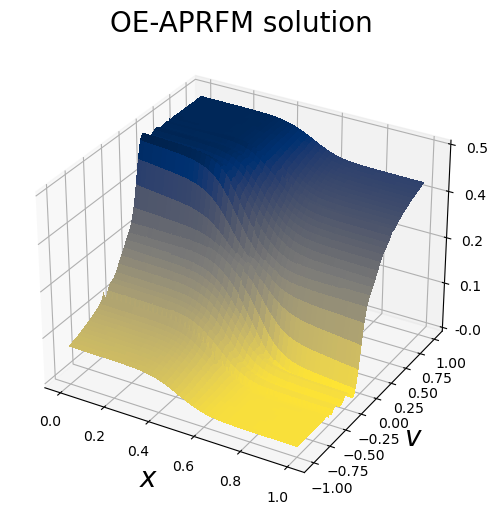

In [26]:
# 第一张图：参考解 3D
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(1, 1, 1, projection="3d")
surf1 = ax1.plot_surface(X, V, F, cmap="cividis_r",

                         linewidth=0, antialiased=False)
ax1.set_xlabel(r"$x$", font_format)
ax1.set_ylabel(r"$v$", font_format)
ax1.zaxis.set_major_locator(LinearLocator(5))
ax1.zaxis.set_major_formatter("{x:.01f}")
ax1.set_title("Reference solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
fig.colorbar(surf1, shrink=0.5, aspect=5)
plt.show()
plt.close()

# 第二张图：OE-APRFM 解 3D
fig = plt.figure(figsize=(8, 6))
ax2 = fig.add_subplot(1, 1, 1, projection="3d")

surf2 = ax2.plot_surface(X, V, F_hat, cmap="cividis_r",
                         linewidth=0, antialiased=False)
ax2.set_xlabel(r"$x$", font_format)
ax2.set_ylabel(r"$v$", font_format)
ax2.set_title("OE-APRFM solution", font_format)
ax2.zaxis.set_major_locator(LinearLocator(5))
ax2.zaxis.set_major_formatter("{x:.01f}")
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["right"].set_linewidth(2)
ax2.spines["top"].set_linewidth(2)
fig.colorbaplt.show()
plt.close()

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman, Times New Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman, Times New Roman


findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman, Times New Roman


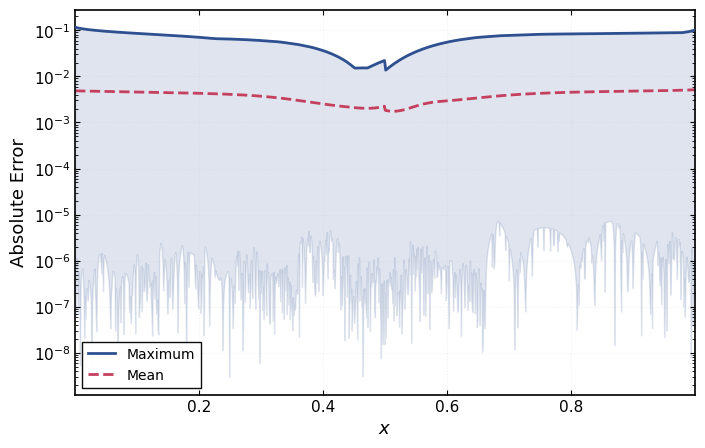

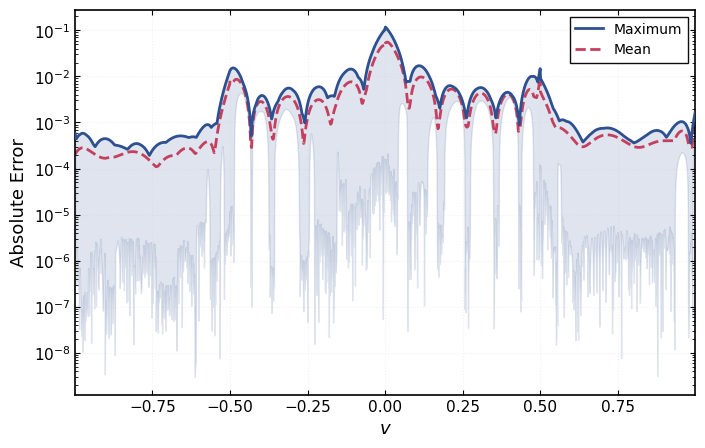

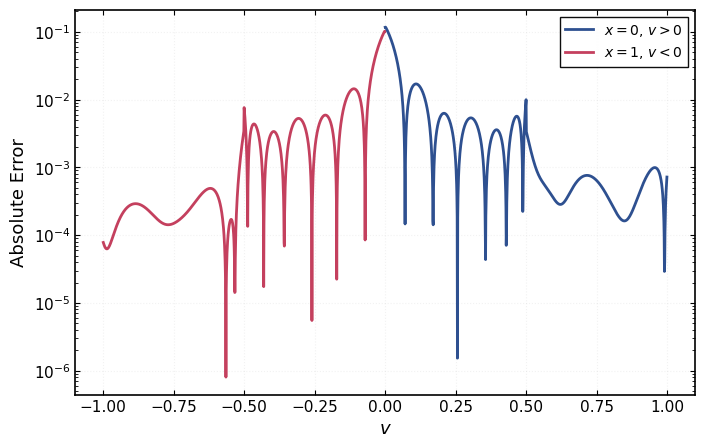

In [ ]:
# ========== Error Distribution Visualization ==========
# Ensure numpy arrays are defined
mesh_x_np = np.asarray(mesh_x)
mesh_v_np = np.asarray(mesh_v)
F_np = np.asarray(F)
F_hat_np = np.asarray(F_hat)

# Ensure F and F_hat are numpy arrays
F = F_np
F_hat = F_hat_np

# Compute errors
error = np.abs(F - F_hat)

# Set academic plotting style
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman"],
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 1.8,
    "grid.linewidth": 0.8,
})

# Define unified professional color palette (blue-red scheme)
colors = {
    "primary": "#2E5090",  # Deep blue
    "secondary": "#C4405E",  # Deep rose
    "tertiary": "#5D8AA8",  # Steel blue
    "quaternary": "#A8717A",  # Dusty rose
    "grid": "#CCCCCC",
    "light_blue": "#7BA3C4",
    "light_red": "#D17A8D",
}

# ========== Figure 1: Error along x ==========
plt.figure(figsize=(8, 5))
error_max_x = np.max(error, axis=0)
error_mean_x = np.mean(error, axis=0)
error_min_x = np.min(error, axis=0)
plt.semilogy(
    mesh_x_np,
    error_max_x,
    "-",
    color=colors["primary"],
    linewidth=2,
    label="Maximum",
    zorder=3,
)
plt.semilogy(
    mesh_x_np,
    error_mean_x,
    "--",
    color=colors["secondary"],
    linewidth=2,
    label="Mean",
    zorder=2,
)
plt.fill_between(
    mesh_x_np, error_min_x, error_max_x, alpha=0.15, color=colors["primary"], zorder=1
)
plt.xlabel(r"$x$", fontsize=13)
plt.ylabel("Absolute Error", fontsize=13)
# plt.title("Error along x", fontsize=13, pad=8)
plt.legend(
    loc="best",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
    fancybox=False,
    shadow=False,
)
plt.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
ax = plt.gca()
ax.tick_params(direction="in", which="both", top=True, right=True)
ax.set_xlim([mesh_x_np[0], mesh_x_np[-1]])
plt.show()
plt.close()

# ========== Figure 2: Error along v ==========
plt.figure(figsize=(8, 5))
error_max_v = np.max(error, axis=1)
error_mean_v = np.mean(error, axis=1)
error_min_v = np.min(error, axis=1)
plt.semilogy(
    mesh_v_np,
    error_max_v,
    "-",
    color=colors["primary"],
    linewidth=2,
    label="Maximum",
    zorder=3,
)
plt.semilogy(
    mesh_v_np,
    error_mean_v,
    "--",
    color=colors["secondary"],
    linewidth=2,
    label="Mean",
    zorder=2,
)
plt.fill_between(
    mesh_v_np, error_min_v, error_max_v, alpha=0.15, color=colors["primary"], zorder=1
)
plt.xlabel(r"$v$", fontsize=13)
plt.ylabel("Absolute Error", fontsize=13)
# plt.title("Error along v", fontsize=13, pad=8)
plt.legend(
    loc="best",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
    fancybox=False,
    shadow=False,
)
plt.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
ax = plt.gca()
ax.tick_params(direction="in", which="both", top=True, right=True)
ax.set_xlim([mesh_v_np[0], mesh_v_np[-1]])
plt.show()
plt.close()

# ========== Figure 3: Boundary Errors Comparison ==========
plt.figure(figsize=(8, 5))
v_positive_idx = mesh_v_np >= 0
error_left = error[v_positive_idx, 0]
v_positive = mesh_v_np[v_positive_idx]
plt.semilogy(
    v_positive,
    error_left,
    "-",
    color=colors["primary"],
    linewidth=2,
    label=r"$x=0$, $v>0$",
    zorder=3,
)
v_negative_idx = mesh_v_np < 0
error_right = error[v_negative_idx, -1]
v_negative = mesh_v_np[v_negative_idx]
plt.semilogy(
    v_negative,
    error_right,
    "-",
    color=colors["secondary"],
    linewidth=2,
    label=r"$x=1$, $v<0$",
    zorder=2,
)
plt.xlabel(r"$v$", fontsize=13)
plt.ylabel("Absolute Error", fontsize=13)
# plt.title("Boundary Error Comparison", fontsize=13, pad=8)
plt.legend(
    loc="best",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
    fancybox=False,
    shadow=False,
)
plt.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
ax = plt.gca()
ax.tick_params(direction="in", which="both", top=True, right=True)
plt.show()
plt.close()

# Reset matplotlib parameters
plt.rcParams.update(plt.rcParamsDefault)